#### Import Libraries

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

#### Checking GPU

In [2]:
print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
GPU: []


#### Dataset path

In [3]:
DATASET_PATH = r"D:\datasets\glaucoma"

train_dir = os.path.join(DATASET_PATH, "train")
val_dir = os.path.join(DATASET_PATH, "validation")
test_dir = os.path.join(DATASET_PATH, "test")

print(train_dir)

D:\datasets\glaucoma\train


#### Image settings

In [4]:
IMG_SIZE = 224
BATCH_SIZE = 8

In [28]:
print(train_data.samples)
print(val_data.samples)
print(test_data.samples)

4500
564
562


#### Image preprocessing

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255)

val_datagen = ImageDataGenerator(rescale=1./255)

test_datagen = ImageDataGenerator(rescale=1./255)

#### Load Training Dataset

In [6]:
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

Found 4500 images belonging to 2 classes.


#### Load Validation dataset

In [7]:
val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

Found 564 images belonging to 2 classes.


#### Load test dataset

In [8]:
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 562 images belonging to 2 classes.


In [9]:
print(train_data.class_indices)

{'glaucoma': 0, 'normal': 1}


#### Visualize images

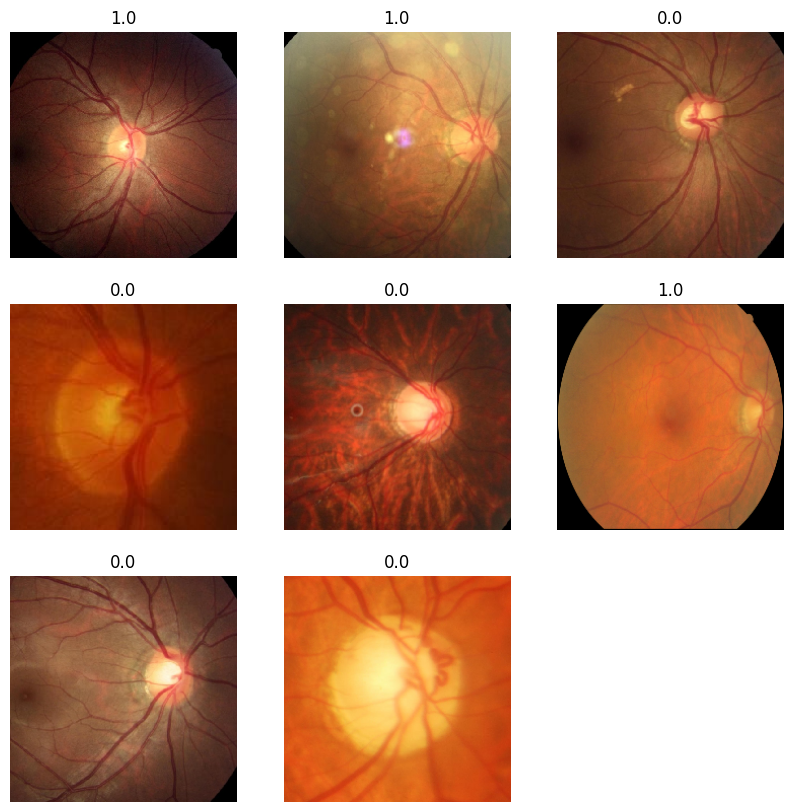

In [ ]:
images, labels = next(train_data)

plt.figure(figsize=(10,10))

for i in range(len(images)):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.title(labels[i])
    plt.axis("off")

plt.show()

In [15]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras import layers, models

#### Loading the base model

In [16]:
base_model = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


#### freeze the base model

In [18]:
base_model.trainable = False

#### Build the classifier head

In [20]:
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.4)(x)
output = layers.Dense(1, activation="sigmoid")(x)

#### Create the full model

In [22]:
model = models.Model(inputs=base_model.input, outputs=output)

#### Compile the model

In [23]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

#### View the architecture

In [24]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,168,833 (27.35 MB)

 Trainable params: 131,329 (513.00 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

#### Train the DenseNet121 model

In [25]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 225s 359ms/step - accuracy: 0.7273 - loss: 0.5378 - val_accuracy: 0.7926 - val_loss: 0.4436
Epoch 2/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 159s 282ms/step - accuracy: 0.8104 - loss: 0.4263 - val_accuracy: 0.8138 - val_loss: 0.4000
Epoch 3/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 154s 273ms/step - accuracy: 0.8220 - loss: 0.3928 - val_accuracy: 0.8351 - val_loss: 0.3779
Epoch 4/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 154s 274ms/step - accuracy: 0.8353 - loss: 0.3686 - val_accuracy: 0.8067 - val_loss: 0.3964
Epoch 5/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 153s 271ms/step - accuracy: 0.8420 - loss: 0.3513 - val_accuracy: 0.8440 - val_loss: 0.3620
Epoch 6/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 153s 272ms/step - accuracy: 0.8516 - loss: 0.3348 - val_accuracy: 0.7660 - val_loss: 0.4273
Epoch 7/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 154s 273ms/step - accuracy: 0.8547 - loss: 0.3203 - val_accuracy: 0.8617 - val_loss: 0.3316
Epoch 8/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 154s 273ms/step - accuracy: 0.8553 -

#### Evaluating on test data

In [26]:
test_loss, test_accuracy = model.evaluate(test_data)

print("Test accuracy:", test_accuracy)

71/71 ━━━━━━━━━━━━━━━━━━━━ 40s 572ms/step - accuracy: 0.8452 - loss: 0.3406
Test accuracy: 0.8451957106590271


#### Saving the model

In [27]:
model.save(r"D:\glaucoma_models\glaucoma_densenet121.h5")

#### ROC-AUC

In [29]:
from sklearn.metrics import roc_curve, auc
import numpy as np

In [30]:
y_pred = model.predict(test_data)
y_true = test_data.classes

71/71 ━━━━━━━━━━━━━━━━━━━━ 27s 335ms/step


In [31]:
fpr, tpr, thresholds = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)

print("AUC:", roc_auc)

AUC: 0.924810982636998


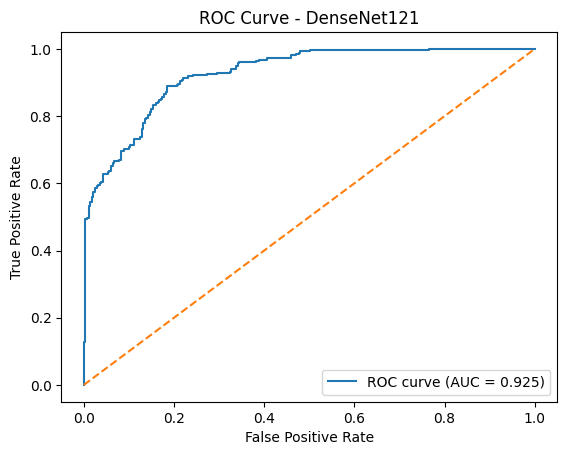

In [32]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(fpr, tpr, label="ROC curve (AUC = %0.3f)" % roc_auc)
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - DenseNet121")
plt.legend()

plt.show()

In [33]:
print(train_data.class_indices)

{'glaucoma': 0, 'normal': 1}


In [34]:
y_pred_glaucoma = 1 - y_pred

In [35]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_true, y_pred_glaucoma)
roc_auc = auc(fpr, tpr)

print("AUC (Glaucoma detection):", roc_auc)

AUC (Glaucoma detection): 0.07518901736300199


In [36]:
print(min(y_pred), max(y_pred))

[1.8523426e-06] [0.99999875]


## Model 2

In [47]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

In [49]:
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 4500 images belonging to 2 classes.
Found 564 images belonging to 2 classes.
Found 562 images belonging to 2 classes.


#### Importing EfficientNet

In [51]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

In [52]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

In [53]:
base_model.trainable = False

In [54]:
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.4)(x)
output = layers.Dense(1, activation="sigmoid")(x)

In [55]:
model_eff = models.Model(inputs=base_model.input, outputs=output)

#### Compile the model

In [56]:
model_eff.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
model_eff.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

: 

: 

#### Training

In [57]:
history_eff = model_eff.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 183s 307ms/step - accuracy: 0.7673 - loss: 0.4747 - val_accuracy: 0.8085 - val_loss: 0.4190
Epoch 2/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 77s 136ms/step - accuracy: 0.8309 - loss: 0.3679 - val_accuracy: 0.8457 - val_loss: 0.3535
Epoch 3/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 75s 133ms/step - accuracy: 0.8449 - loss: 0.3436 - val_accuracy: 0.8475 - val_loss: 0.3427
Epoch 4/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 75s 133ms/step - accuracy: 0.8564 - loss: 0.3241 - val_accuracy: 0.8457 - val_loss: 0.3310
Epoch 5/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 75s 133ms/step - accuracy: 0.8611 - loss: 0.2991 - val_accuracy: 0.8511 - val_loss: 0.3141
Epoch 6/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 75s 132ms/step - accuracy: 0.8704 - loss: 0.2872 - val_accuracy: 0.8546 - val_loss: 0.3172
Epoch 7/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 75s 133ms/step - accuracy: 0.8731 - loss: 0.2854 - val_accuracy: 0.8670 - val_loss: 0.3185
Epoch 8/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 76s 135ms/step - accuracy: 0.8776 - loss: 

In [58]:
test_loss, test_accuracy = model_eff.evaluate(test_data)

print("EfficientNet Test accuracy:", test_accuracy)

71/71 ━━━━━━━━━━━━━━━━━━━━ 19s 268ms/step - accuracy: 0.8470 - loss: 0.3365
EfficientNet Test accuracy: 0.8469750881195068


In [59]:
y_pred_eff = model_eff.predict(test_data)
y_true = test_data.classes

from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_true, y_pred_eff)
roc_auc_eff = auc(fpr, tpr)

print("EfficientNet AUC:", roc_auc_eff)

71/71 ━━━━━━━━━━━━━━━━━━━━ 15s 184ms/step
EfficientNet AUC: 0.9380326996871874
